In [15]:
import geopandas as gpd
import matplotlib.pyplot as plt 
import shapely 
import pandas as pd

### Satlink Data

In [2]:
### Cords   5.883611, -162.078333
file = r"C:\FATE\Palmyra FAD Watch GIS data for NASA (Nov 2024)-selected\Satlink_FAD_positions_sets_070123_063024_PointsToLine.shp"
Sat_data = gpd.read_file(file)
Sat_data["startpoint"] = shapely.get_point(Sat_data['geometry'], 0) ## creates a start point for the data, but maybe it is actually the end point?
splice = Sat_data[0:20]
print(Sat_data.shape)

(2183, 18)


In [ ]:
print(splice.columns)

Index(['Shape_Leng', 'Set_3', 'BuoyName', 'Name_ID', 'MinOfTimes',
       'MaxOfTimes', 'MinOfDate', 'MaxOfDate', 'Yr_min', 'Mon_min', 'Day_min',
       'Yr_max', 'Mon_max', 'Day_max', 'Diff_days', 'Distance_n', 'geometry',
       'startpoint'],
      dtype='object')


In [4]:
line = splice['geometry'][0]
startpoint = shapely.get_point(line, 0)
print(startpoint)


POINT (-163.57891999999998 4.795900000000074)


C:\Users\czerfass\AppData\Local\Temp\3\ipykernel_4896\4152523389.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


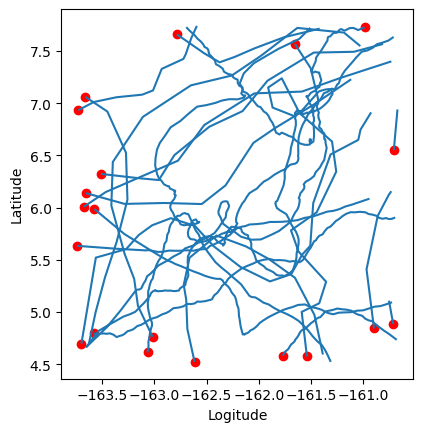

In [5]:
fig , ax = plt.subplots()
splice.plot(ax= ax)
splice["startpoint"].plot(ax= ax, color = "r")
ax.set_xlabel("Logitude")
ax.set_ylabel("Latitude")
fig.show()

### MI_Fad data

In [19]:
MI_fad = r"C:\FATE\Palmyra FAD Watch GIS data for NASA (Nov 2024)-selected\MI_FAD_positions_sets_062821_063024_PointsToLine"
MI_data = gpd.read_file(MI_fad)


In [23]:
MI_data["MinOfDate"].max()
MI_data["MinOfDate"].min()

Timestamp('2021-06-28 00:00:00')

In [10]:
MI_data = MI_data.sort_values('MinOfDate')

C:\Users\czerfass\AppData\Local\Temp\3\ipykernel_4896\104553290.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


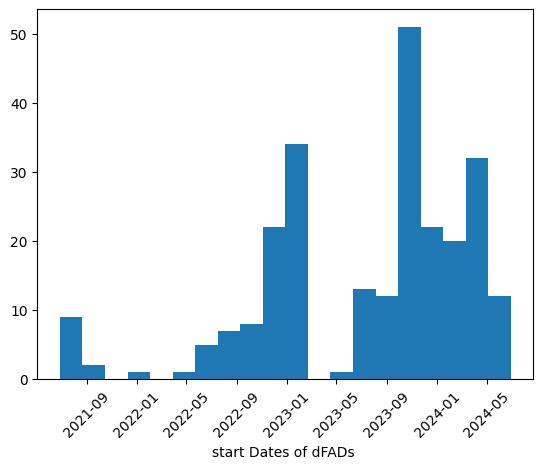

In [11]:
fig, ax = plt.subplots()
ax.hist(MI_data['MinOfDate'], bins = 20)
ax.tick_params(axis='x', labelrotation=45)
ax.set_xlabel("start Dates of dFADs ")
fig.show()

### Combining File

In [17]:
rename_dic = {"NAME" : "BuoyName", "Name_ID_ad": "Name_ID", "Length_nm":"Distance_n"}
MI_data.rename(columns=rename_dic , inplace=True)
print(MI_data.columns)

combfile = pd.concat([MI_data, Sat_data])
print(combfile.shape)

Index(['Shape_Leng', 'Set_3', 'BuoyName', 'Name_ID', 'MinOfTimes',
       'MaxOfTimes', 'MinOfDate', 'MaxOfDate', 'Yr_min', 'Mon_min', 'Day_min',
       'Yr_max', 'Mon_max', 'Day_max', 'Diff_days', 'Distance_n', 'geometry'],
      dtype='object')
(2435, 18)
